# Lorenz '96 Two-Tier — Slow-Fast Multiscale Chaos

The two-tier Lorenz '96 system couples a set of **slow** large-scale
variables $X_k$ to a set of **fast** small-scale variables $Y_{j,k}$.
It is the standard test bed for studying multiscale dynamics,
sub-grid parameterization, and stochastic closures.

**What you'll learn:**

1. How slow and fast variables interact through coupling
2. How the Hovmoller diagram reveals the multiscale structure
3. How coupling strength controls fast-variable activity
4. How to differentiate through a multiscale simulation

## Background

The system consists of $D_x$ slow variables $X_k$ and
$D_y \times D_x$ fast variables $Y_{j,k}$:

$$
\frac{dX_k}{dt}
= (X_{k+1} - X_{k-2})\, X_{k-1} - X_k + F
  - \frac{hc}{b} \sum_{j=1}^{D_y} Y_{j,k}
$$

$$
\frac{dY_{j,k}}{dt}
= cb\,(Y_{j+1,k} - Y_{j-2,k})\, Y_{j-1,k} - c\, Y_{j,k}
  + \frac{hc}{b}\, X_k
$$

The key parameters are:

| Parameter | Role | Standard value |
|-----------|------|----------------|
| $F$ | External forcing on slow variables | 18 |
| $h$ | Coupling coefficient | 1 |
| $b$ | Amplitude ratio (fast / slow) | 10 |
| $c$ | Time-scale ratio (fast / slow) | 10 |

The fast variables evolve $c = 10$ times faster than the slow
variables and have $b = 10$ times smaller amplitude. The coupling
term $hc/b$ transfers energy between scales.

In [1]:
from __future__ import annotations

import diffrax as dfx
import einops
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt

from somax.models import L96TState, Lorenz96t

## 1. Create the model

We use $D_x = 36$ slow variables and $D_y = 10$ fast variables
per slow variable (360 fast variables total).

In [2]:
Dx, Dy = 36, 10
model = Lorenz96t.create(F=18.0, h=1.0, b=10.0, c=10.0)
print(model)

Lorenz96t(
  params=L96TParams(F=weak_f32[], h=weak_f32[], b=weak_f32[], c=weak_f32[])
)


## 2. Forward simulation

The fast variables require a small time step. We integrate for
2 time units (roughly 10 days in the L96 convention) and save
at a moderate output rate.

In [3]:
state0 = L96TState.init_state(ndims=(Dx, Dy), noise=0.01, b=10.0)

t0, t1, dt = 0.0, 2.0, 0.0005
ts = jnp.arange(t0, t1, 0.005)  # save every 0.005

sol = model.integrate(
    state0,
    t0=t0,
    t1=t1,
    dt=dt,
    saveat=dfx.SaveAt(ts=ts),
)

print(f"Slow variables: {sol.ys.x.shape}")  # (T, Dx)
print(f"Fast variables: {sol.ys.y.shape}")  # (T, Dy*Dx)

Slow variables: (400, 36)
Fast variables: (400, 360)


## 3. Slow and fast time series

The slow variables look like noisy oscillations (similar to
standard L96), while the fast variables show rapid fluctuations
modulated by the slow-variable envelope.

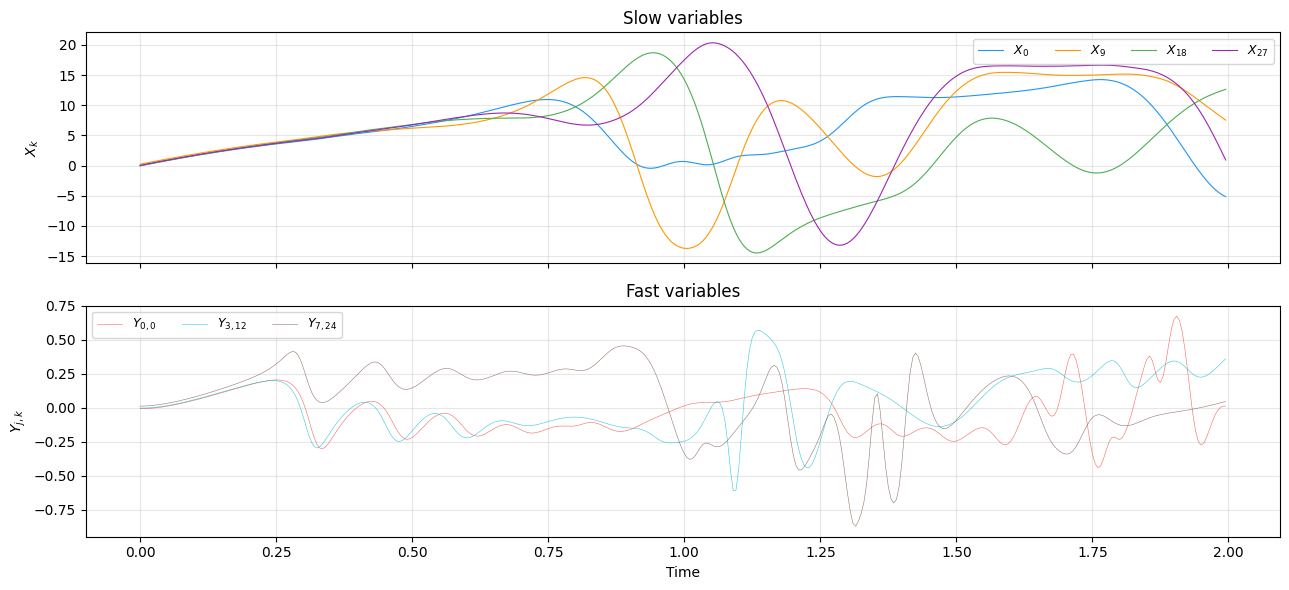

In [4]:
colors_slow = ["#2196F3", "#FF9800", "#4CAF50", "#9C27B0"]
colors_fast = ["#F44336", "#00BCD4", "#795548"]

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

# Slow variables
ax = axes[0]
for idx, c in zip([0, 9, 18, 27], colors_slow, strict=True):
    ax.plot(ts, sol.ys.x[:, idx], lw=0.8, color=c, label=f"$X_{{{idx}}}$")
ax.set_ylabel("$X_k$")
ax.set_title("Slow variables")
ax.legend(fontsize=9, ncol=4)
ax.grid(True, alpha=0.3)

# Fast variables (a few from different slow-variable sectors)
ax = axes[1]
y_2d = einops.rearrange(sol.ys.y, "T (Dy Dx) -> T Dy Dx", Dy=Dy, Dx=Dx)
for j_idx, k_idx, c in zip([0, 3, 7], [0, 12, 24], colors_fast, strict=True):
    ax.plot(
        ts,
        y_2d[:, j_idx, k_idx],
        lw=0.4,
        alpha=0.8,
        color=c,
        label=f"$Y_{{{j_idx},{k_idx}}}$",
    )
ax.set_xlabel("Time")
ax.set_ylabel("$Y_{j,k}$")
ax.set_title("Fast variables")
ax.legend(fontsize=9, ncol=3)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Hovmoller diagrams — slow vs fast

The slow-variable Hovmoller shows the familiar wave propagation.
The fast-variable Hovmoller (averaged over the $j$-index) reveals
the small-scale activity modulated by the large-scale pattern.

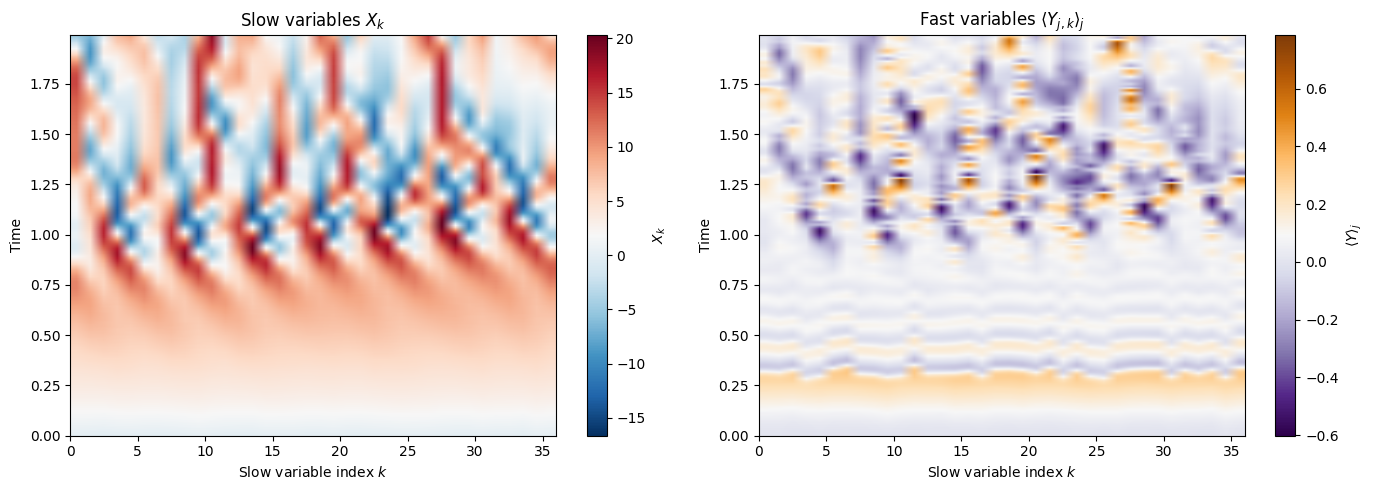

In [5]:
y_2d_full = einops.rearrange(sol.ys.y, "T (Dy Dx) -> T Dy Dx", Dy=Dy, Dx=Dx)
y_mean_over_j = jnp.mean(y_2d_full, axis=1)  # (T, Dx)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Slow
im0 = axes[0].imshow(
    sol.ys.x,
    aspect="auto",
    origin="lower",
    cmap="RdBu_r",
    extent=[0, Dx, float(ts[0]), float(ts[-1])],
    interpolation="bilinear",
)
axes[0].set_xlabel("Slow variable index $k$")
axes[0].set_ylabel("Time")
axes[0].set_title("Slow variables $X_k$")
plt.colorbar(im0, ax=axes[0], label="$X_k$")

# Fast (j-averaged)
im1 = axes[1].imshow(
    y_mean_over_j,
    aspect="auto",
    origin="lower",
    cmap="PuOr_r",
    extent=[0, Dx, float(ts[0]), float(ts[-1])],
    interpolation="bilinear",
)
axes[1].set_xlabel("Slow variable index $k$")
axes[1].set_ylabel("Time")
axes[1].set_title(r"Fast variables $\langle Y_{j,k} \rangle_j$")
plt.colorbar(im1, ax=axes[1], label=r"$\langle Y \rangle_j$")

plt.tight_layout()
plt.show()

## 5. Energy partition

The total energy splits between slow and fast components. The
fast variables carry less energy per mode but there are $D_y$
times as many of them.

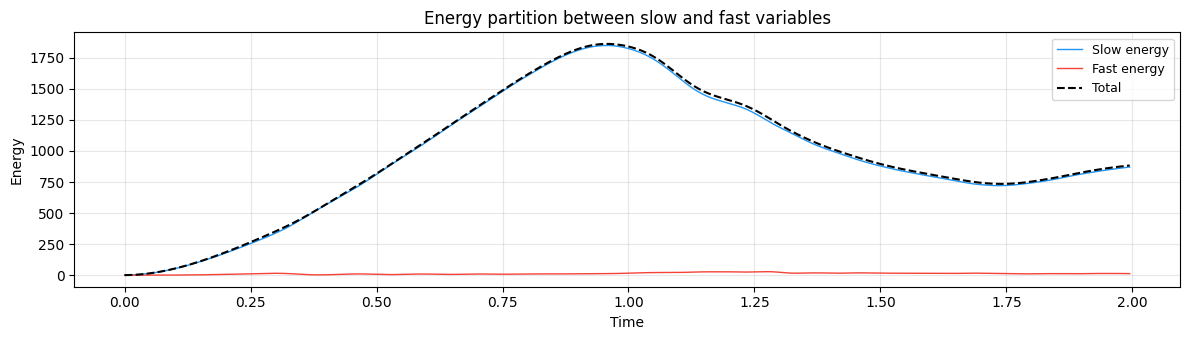

In [6]:
slow_energy = 0.5 * jnp.sum(sol.ys.x**2, axis=1)
fast_energy = 0.5 * jnp.sum(sol.ys.y**2, axis=1)

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(ts, slow_energy, lw=1, color="#2196F3", label="Slow energy")
ax.plot(ts, fast_energy, lw=1, color="#F44336", label="Fast energy")
ax.plot(ts, slow_energy + fast_energy, lw=1.5, color="k", ls="--", label="Total")
ax.set_xlabel("Time")
ax.set_ylabel("Energy")
ax.set_title("Energy partition between slow and fast variables")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Coupling strength

The coupling coefficient $h$ controls how strongly the fast
variables feed back onto the slow variables. We compare three
regimes: uncoupled ($h = 0$), weakly coupled ($h = 0.5$),
and strongly coupled ($h = 1$).

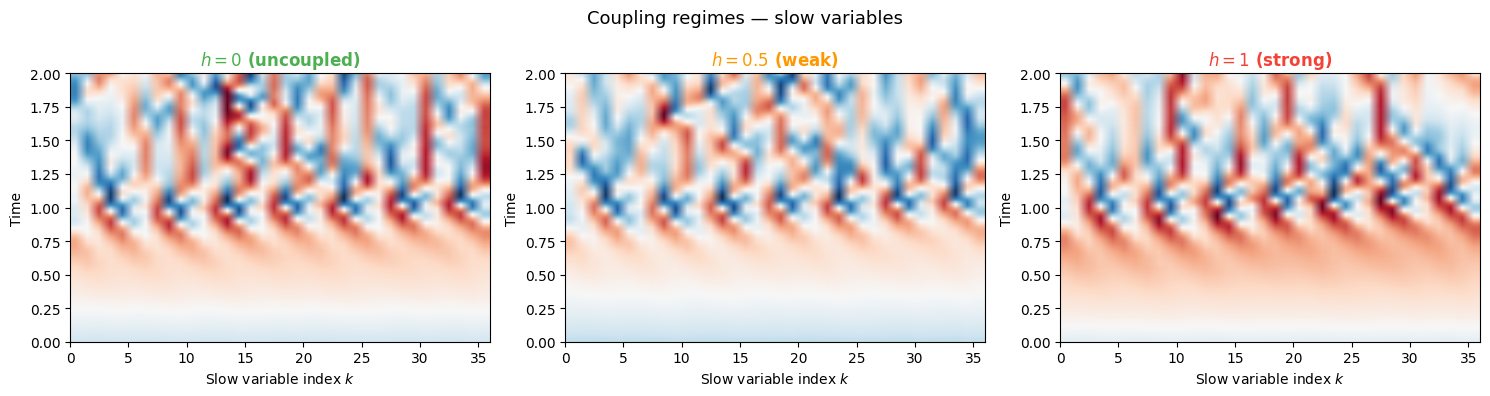

In [7]:
h_values = [0.0, 0.5, 1.0]
h_labels = ["$h=0$ (uncoupled)", "$h=0.5$ (weak)", "$h=1$ (strong)"]
h_colors = ["#4CAF50", "#FF9800", "#F44336"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, h_val, label, color in zip(axes, h_values, h_labels, h_colors, strict=True):
    m = Lorenz96t.create(F=18.0, h=h_val, b=10.0, c=10.0)
    s0 = L96TState.init_state(ndims=(Dx, Dy), noise=0.01, b=10.0)
    s = m.integrate(s0, t0=0.0, t1=2.0, dt=0.0005, saveat=dfx.SaveAt(ts=ts))
    ax.imshow(
        s.ys.x,
        aspect="auto",
        origin="lower",
        cmap="RdBu_r",
        extent=[0, Dx, 0, 2],
        interpolation="bilinear",
    )
    ax.set_xlabel("Slow variable index $k$")
    ax.set_ylabel("Time")
    ax.set_title(label, color=color, fontweight="bold")

plt.suptitle("Coupling regimes — slow variables", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Adjoint methods and differentiation

Differentiating through a stiff multiscale ODE is more challenging
than a single-scale system because the fast variables demand many
time steps. diffrax provides three adjoint methods:

| Adjoint | Memory | Gradients | Use case |
|---------|--------|-----------|----------|
| `RecursiveCheckpointAdjoint` | $O(\sqrt{N})$ | Exact | **Default** |
| `DirectAdjoint` | $O(N)$ | Exact | Short windows |
| `BacksolveAdjoint` | $O(1)$ | Approx | Long windows |
| `ImplicitAdjoint` | $O(1)$ | Exact | Steady states |

- **`RecursiveCheckpointAdjoint`** (the default) uses optimal
  checkpointing: re-computes forward steps from saved checkpoints,
  giving exact gradients with $O(\sqrt{N})$ memory.
- **`DirectAdjoint`** stores the entire forward trajectory —
  exact but $O(N)$ memory.
- **`BacksolveAdjoint`** solves the continuous adjoint ODE
  backwards with $O(1)$ memory. Gradients are approximate.
- **`ImplicitAdjoint`** uses the implicit function theorem:
  $du^*/d\theta = -(dg/du)^{-1}\, dg/d\theta$. Exact and
  $O(1)$ memory, but only for steady-state / fixed-point solves.

For this system with $dt = 5 \times 10^{-4}$, even a short window
of $T = 0.5$ requires 1000 steps. `RecursiveCheckpointAdjoint` is
the best default because it avoids storing all 1000 forward states.

### 7a. Gradient w.r.t. parameters

**Use case: parameter estimation.** All four coupling parameters
$(F, h, b, c)$ are differentiable. The adjoint equations are:

$$
\frac{\partial \mathcal{L}}{\partial \theta}
= \int_0^T \lambda(t)^\top
  \frac{\partial f}{\partial \theta}\, dt,
\qquad \theta = (F, h, b, c)
$$

In [8]:
state0_grad = L96TState.init_state(ndims=(Dx, Dy), noise=0.01, b=10.0)


@eqx.filter_grad
def grad_params(model):
    sol = model.integrate(state0_grad, t0=0.0, t1=0.5, dt=0.0005)
    return jnp.sum(sol.ys.x**2)


grads_theta = grad_params(model)
print("--- Gradient w.r.t. parameters ---")
print(f"  dL/dF = {grads_theta.params.F:.4f}")
print(f"  dL/dh = {grads_theta.params.h:.4f}")
print(f"  dL/db = {grads_theta.params.b:.4f}")
print(f"  dL/dc = {grads_theta.params.c:.4f}")

--- Gradient w.r.t. parameters ---
  dL/dF = 193.4378
  dL/dh = -128.4092
  dL/db = 39.7463
  dL/dc = 0.3340


### 7b. Gradient w.r.t. initial state

**Use case: 4D-Var.** Find the initial condition
$(\mathbf{X}_0, \mathbf{Y}_0)$ that best fits observations.
The gradient is the adjoint state at $t = 0$:

$$
\frac{\partial \mathcal{L}}{\partial \mathbf{u}_0}
= \lambda(0),
\qquad \mathbf{u}_0 = (\mathbf{X}_0, \mathbf{Y}_0)
$$

In practice one often assimilates only the slow variables and
lets the fast variables spin up.

In [9]:
def loss_state(state0):
    sol = model.integrate(state0, t0=0.0, t1=0.5, dt=0.0005)
    return jnp.sum(sol.ys.x**2)


grads_u0 = jax.grad(loss_state)(state0_grad)

print("--- Gradient w.r.t. initial state ---")
print(f"  dL/d(X0) shape: {grads_u0.x.shape}")
print(f"  dL/d(X0) norm:  {jnp.linalg.norm(grads_u0.x):.4f}")
print(f"  dL/d(Y0) shape: {grads_u0.y.shape}")
print(f"  dL/d(Y0) norm:  {jnp.linalg.norm(grads_u0.y):.4f}")

--- Gradient w.r.t. initial state ---
  dL/d(X0) shape: (36,)


  dL/d(X0) norm:  52.9541
  dL/d(Y0) shape: (360,)
  dL/d(Y0) norm:  1425.0918


### 7c. Joint gradient — parameters and state

**Use case: weak-constraint 4D-Var.** Simultaneously optimize
the initial condition and all coupling parameters.

In [10]:
def loss_joint(state0, model):
    sol = model.integrate(state0, t0=0.0, t1=0.5, dt=0.0005)
    return jnp.sum(sol.ys.x**2)


grads_u0_joint, grads_model_joint = jax.grad(loss_joint, argnums=(0, 1))(
    state0_grad, model
)

print("--- Joint gradient ---")
print(f"  dL/dF         = {grads_model_joint.params.F:.4f}")
print(f"  dL/dh         = {grads_model_joint.params.h:.4f}")
print(f"  dL/d(X0) norm = {jnp.linalg.norm(grads_u0_joint.x):.4f}")
print(f"  dL/d(Y0) norm = {jnp.linalg.norm(grads_u0_joint.y):.4f}")

--- Joint gradient ---
  dL/dF         = 193.4378
  dL/dh         = -128.4092
  dL/d(X0) norm = 52.9541
  dL/d(Y0) norm = 1425.0918


## 8. Ensemble divergence

We launch 20 ensemble members and track how the slow-variable
spread grows over time.

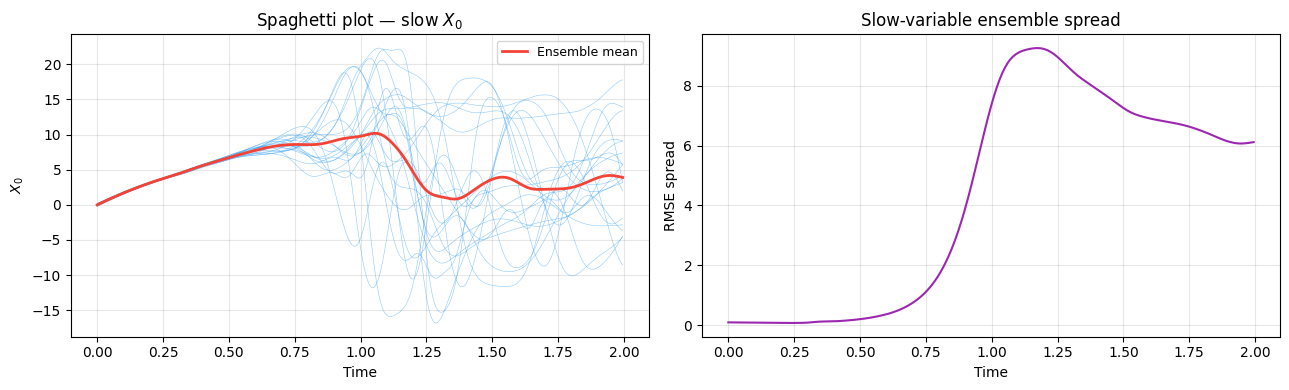

In [11]:
n_ensemble = 20
key = jrandom.PRNGKey(7)
key_x, key_y = jrandom.split(key)

x0 = 0.1 * jrandom.normal(key_x, shape=(n_ensemble, Dx))
y0 = 0.01 * jrandom.normal(key_y, shape=(n_ensemble, Dy * Dx))
ensemble_states = L96TState(x=x0, y=y0)

ts_ens = jnp.arange(0.0, 2.0, 0.005)


def integrate_one(state0):
    return model.integrate(
        state0,
        t0=0.0,
        t1=2.0,
        dt=0.0005,
        saveat=dfx.SaveAt(ts=ts_ens),
    )


ensemble_sol = eqx.filter_vmap(integrate_one)(ensemble_states)

# Slow-variable ensemble spread
ens_mean_x = jnp.mean(ensemble_sol.ys.x, axis=0)  # (T, Dx)
spread_x = jnp.sqrt(
    jnp.mean((ensemble_sol.ys.x - ens_mean_x[None, :, :]) ** 2, axis=(0, 2))
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Spaghetti — slow variable 0
ax = axes[0]
for j in range(n_ensemble):
    ax.plot(
        ts_ens,
        ensemble_sol.ys.x[j, :, 0],
        lw=0.4,
        alpha=0.5,
        color="#2196F3",
    )
ax.plot(ts_ens, ens_mean_x[:, 0], lw=2, color="#F44336", label="Ensemble mean")
ax.set_xlabel("Time")
ax.set_ylabel("$X_0$")
ax.set_title("Spaghetti plot — slow $X_0$")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Spread
ax = axes[1]
ax.plot(ts_ens, spread_x, lw=1.5, color="#9C27B0")
ax.set_xlabel("Time")
ax.set_ylabel("RMSE spread")
ax.set_title("Slow-variable ensemble spread")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

| Concept | somax API |
|---------|-----------|
| Create a model | `Lorenz96t.create(F=18, h=1, b=10, c=10)` |
| Initial condition | `L96TState.init_state(ndims=(Dx, Dy))` |
| Forward simulation | `model.integrate(state0, t0, t1, dt)` |
| Grad w.r.t. params | `eqx.filter_grad(loss)(model)` — all 4 params |
| Grad w.r.t. state | `jax.grad(loss)(state0)` — dL/d(X0, Y0) |
| Joint grad | `jax.grad(loss, argnums=(0, 1))(state0, model)` |
| Ensemble | `eqx.filter_vmap(integrate_one)(batch_states)` |

**Key takeaways:**

- The fast variables evolve $c = 10$ times faster than the slow
  variables, requiring a small time step ($dt \approx 5 \times 10^{-4}$)
- Coupling ($h > 0$) feeds fast-variable energy back into the slow
  dynamics, modifying the large-scale attractor
- This system is the standard test bed for learned sub-grid
  parameterizations (replacing the fast variables with a closure)